# 最优模型评估与可视化

经过三轮迭代（特征扩充 + Optuna调参 + 多模型集成），汇总最优模型表现：
- **DA (日前电价)**: LightGBM Optuna调参模型 (MAE=17.05)
- **RT (实时电价)**: LGB + CatBoost 加权平均 (MAE=29.11)

**评估维度：**
1. 迭代进展对比
2. 预测 vs 实际时序图
3. 散点图 + 残差分布
4. 按小时/峰谷时段误差
5. 按日期误差 + 高误差日剖析
6. 各方法横向对比

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

sns.set_style("whitegrid")

_CN_FONT_PATHS = [
    "/System/Library/Fonts/Hiragino Sans GB.ttc",
    "/System/Library/Fonts/PingFang.ttc",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/Supplemental/Songti.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf"
]
for _p in _CN_FONT_PATHS:
    if os.path.exists(_p):
        fm.fontManager.addfont(_p)
        _cn_name = fm.FontProperties(fname=_p).get_name()
        matplotlib.rcParams["font.family"] = "sans-serif"
        matplotlib.rcParams["font.sans-serif"] = [_cn_name]
        print(f"中文字体: {_cn_name}")
        break

matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["figure.figsize"] = (14, 5)

OUT = "../output"

# DA best = Optuna-tuned LGB
da = pd.read_csv(f"{OUT}/tuning_da_result.csv", parse_dates=["ts"], index_col="ts")
da.rename(columns={"pred_lgb": "pred_best"}, inplace=True)

# RT best = ensemble weighted average
rt = pd.read_csv(f"{OUT}/ensemble_rt_result.csv", parse_dates=["ts"], index_col="ts")
rt.rename(columns={"pred_wavg": "pred_best"}, inplace=True)

# Add residuals
da["residual"] = da["actual"] - da["pred_best"]
rt["residual"] = rt["actual"] - rt["pred_best"]
da["hour"] = da.index.hour
rt["hour"] = rt.index.hour
da["date"] = da.index.date
rt["date"] = rt.index.date

# Iteration summary
summary = pd.read_csv(f"{OUT}/iteration_summary.csv")

# Ensemble full for method comparison
ens_da = pd.read_csv(f"{OUT}/ensemble_da_result.csv", parse_dates=["ts"], index_col="ts")
ens_rt = pd.read_csv(f"{OUT}/ensemble_rt_result.csv", parse_dates=["ts"], index_col="ts")
seq_da = pd.read_csv(f"{OUT}/sequence_da_result.csv", parse_dates=["ts"], index_col="ts")
seq_rt = pd.read_csv(f"{OUT}/sequence_rt_result.csv", parse_dates=["ts"], index_col="ts")

print(f"DA 测试集: {len(da)} 行, {da.index.min()} ~ {da.index.max()}")
print(f"RT 测试集: {len(rt)} 行, {rt.index.min()} ~ {rt.index.max()}")

中文字体: Hiragino Sans GB
DA 测试集: 720 行, 2026-02-09 00:00:00 ~ 2026-03-10 23:00:00
RT 测试集: 720 行, 2026-02-09 00:00:00 ~ 2026-03-10 23:00:00


## 1. 迭代进展对比

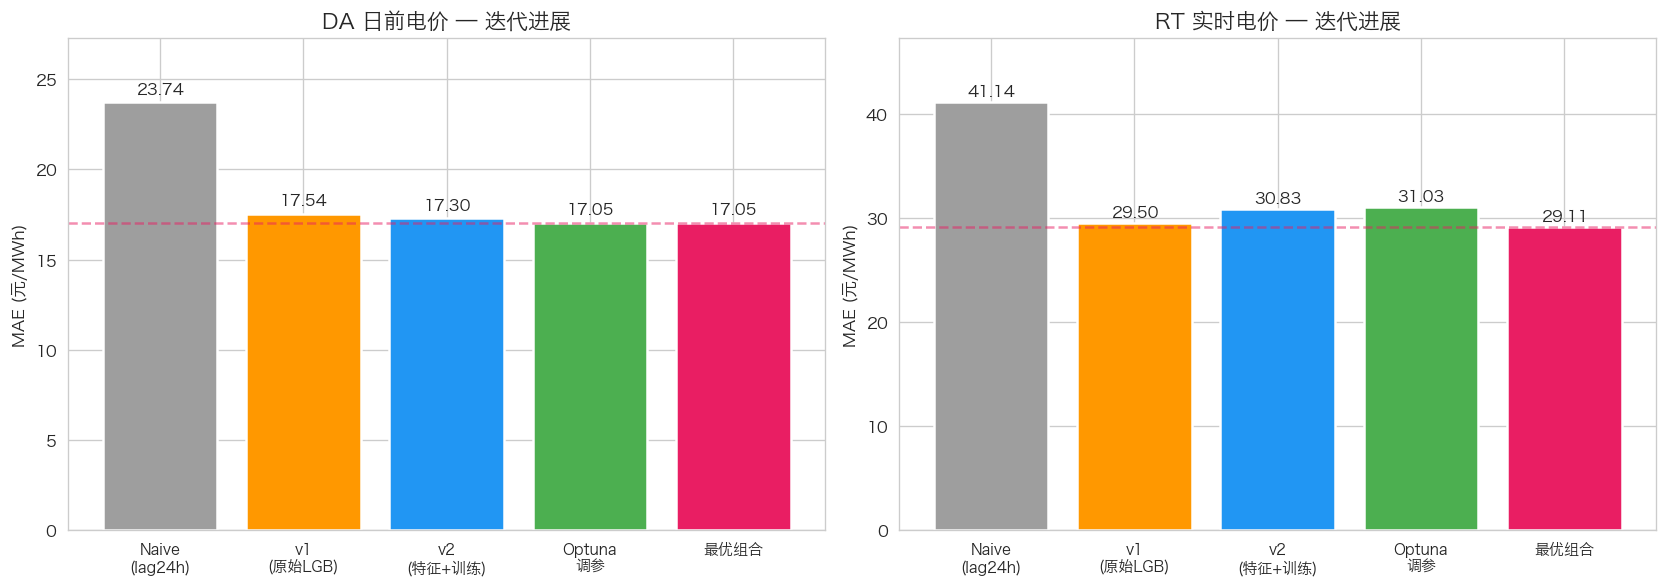

DA: Naive 23.74 → 最优 17.05, 提升 28.2%
RT: Naive 41.14 → 最优 29.11, 提升 29.2%


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stages = ["naive_baseline", "v1_baseline", "v2_baseline", "optuna_tuned", "best_per_model"]
labels = ["Naive\n(lag24h)", "v1\n(原始LGB)", "v2\n(特征+训练)", "Optuna\n调参", "最优组合"]
colors = ["#9E9E9E", "#FF9800", "#2196F3", "#4CAF50", "#E91E63"]

s = summary.set_index("stage")

da_vals = [s.loc[st, "da_mae"] for st in stages]
rt_vals = [s.loc[st, "rt_mae"] for st in stages]

bars1 = axes[0].bar(range(len(stages)), da_vals, color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_xticks(range(len(stages)))
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_ylabel("MAE (元/MWh)")
axes[0].set_title("DA 日前电价 — 迭代进展", fontsize=13, fontweight="bold")
for bar, val in zip(bars1, da_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f"{val:.2f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_ylim(0, max(da_vals) * 1.15)
axes[0].axhline(y=da_vals[-1], color="#E91E63", linestyle="--", alpha=0.5)

bars2 = axes[1].bar(range(len(stages)), rt_vals, color=colors, edgecolor="white", linewidth=1.5)
axes[1].set_xticks(range(len(stages)))
axes[1].set_xticklabels(labels, fontsize=9)
axes[1].set_ylabel("MAE (元/MWh)")
axes[1].set_title("RT 实时电价 — 迭代进展", fontsize=13, fontweight="bold")
for bar, val in zip(bars2, rt_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f"{val:.2f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1].set_ylim(0, max(rt_vals) * 1.15)
axes[1].axhline(y=rt_vals[-1], color="#E91E63", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(f"{OUT}/final_iteration_progress.png", bbox_inches="tight")
plt.show()

improve_da = (1 - da_vals[-1] / da_vals[0]) * 100
improve_rt = (1 - rt_vals[-1] / rt_vals[0]) * 100
print(f"DA: Naive {da_vals[0]:.2f} → 最优 {da_vals[-1]:.2f}, 提升 {improve_da:.1f}%")
print(f"RT: Naive {rt_vals[0]:.2f} → 最优 {rt_vals[-1]:.2f}, 提升 {improve_rt:.1f}%")

## 2. 预测 vs 实际 — 全时段时序图

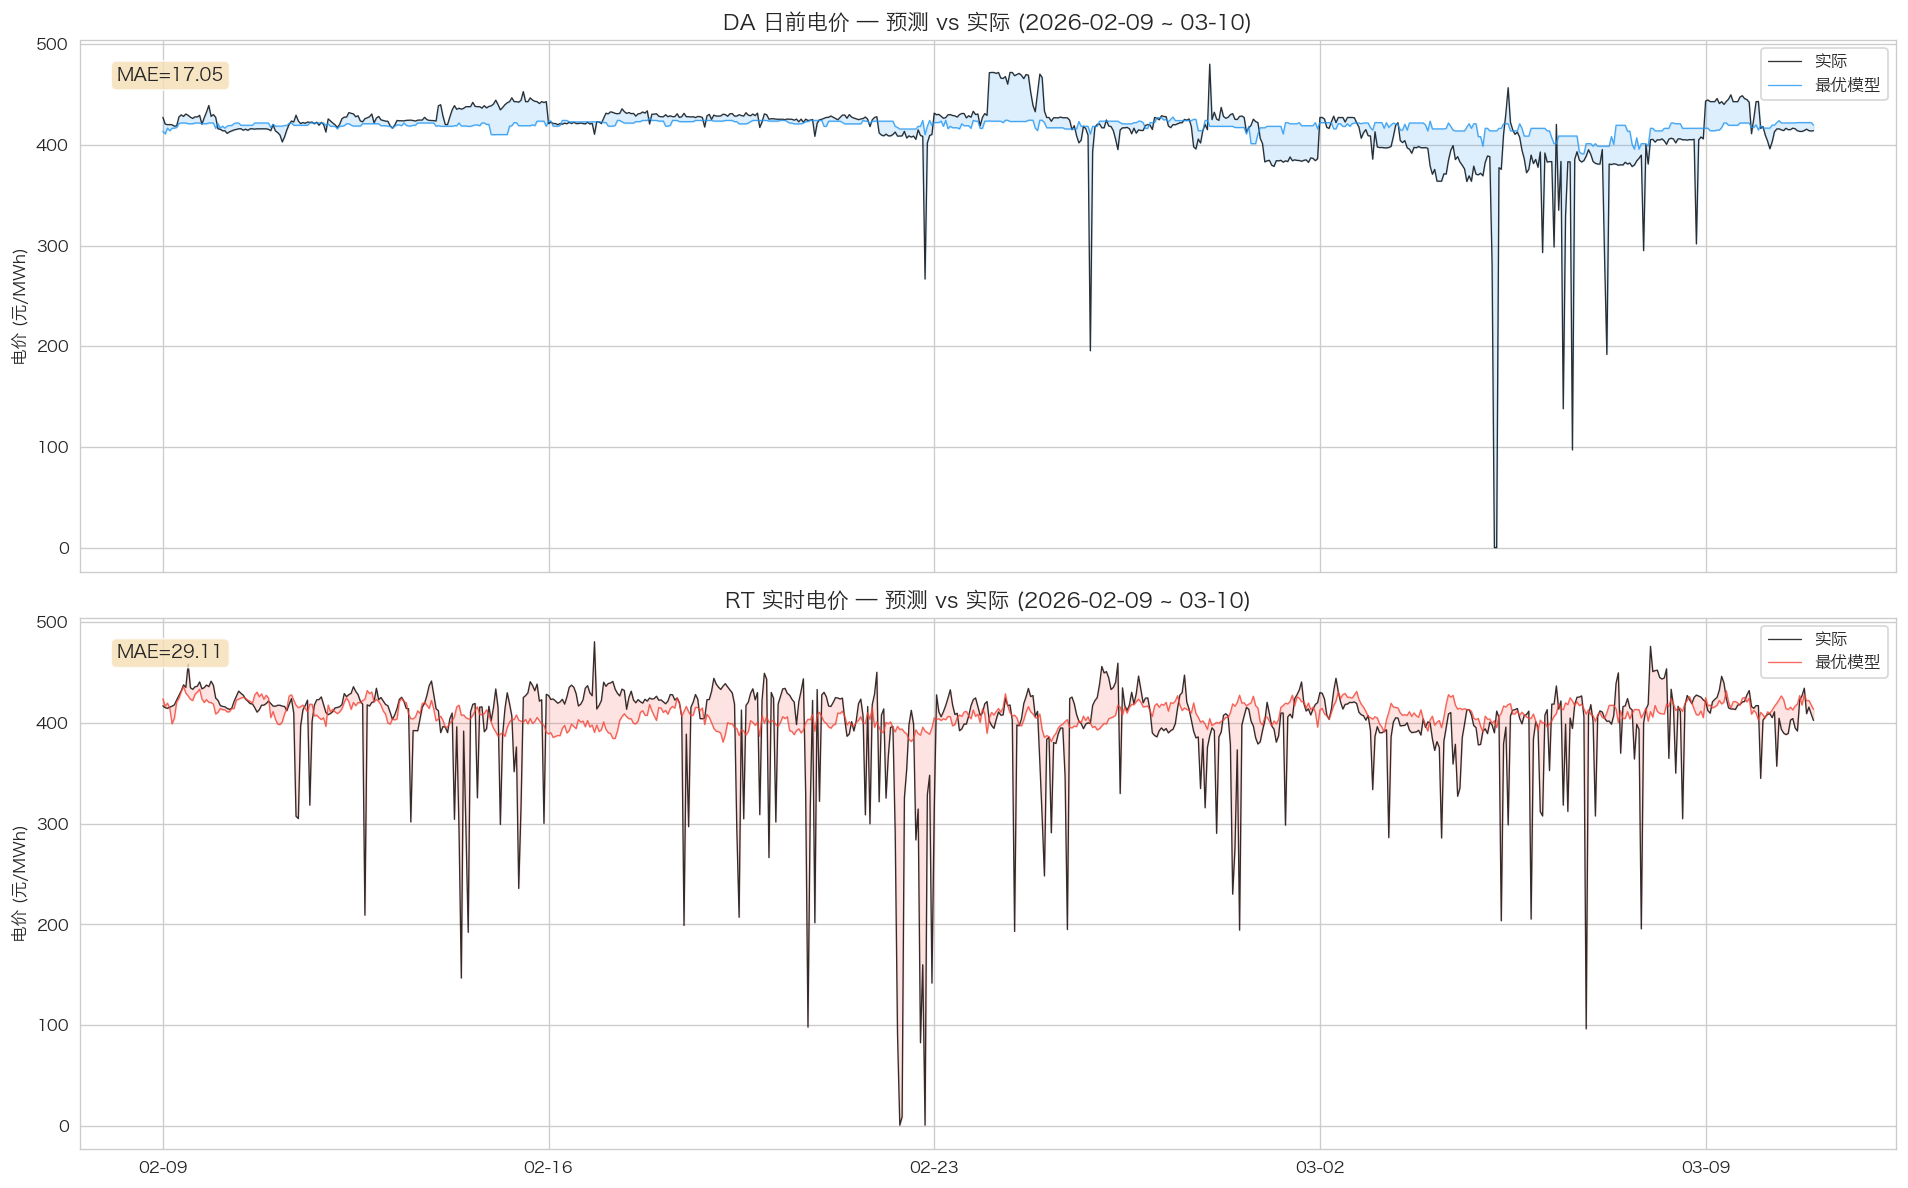

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

for ax, df, name, color in [
    (axes[0], da, "DA 日前电价", "#2196F3"),
    (axes[1], rt, "RT 实时电价", "#F44336"),
]:
    ax.plot(df.index, df["actual"], color="black", linewidth=0.8, alpha=0.8, label="实际")
    ax.plot(df.index, df["pred_best"], color=color, linewidth=0.8, alpha=0.8, label="最优模型")
    ax.fill_between(df.index, df["actual"], df["pred_best"], alpha=0.15, color=color)
    ax.set_ylabel("电价 (元/MWh)")
    ax.set_title(f"{name} — 预测 vs 实际 (2026-02-09 ~ 03-10)", fontsize=13, fontweight="bold")
    ax.legend(loc="upper right", fontsize=10)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

    mae = np.mean(np.abs(df["residual"]))
    ax.text(0.02, 0.95, f"MAE={mae:.2f}", transform=ax.transAxes,
            fontsize=11, verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

plt.tight_layout()
plt.savefig(f"{OUT}/final_pred_vs_actual.png", bbox_inches="tight")
plt.show()

## 3. 单周详细对比 — 缩放视图

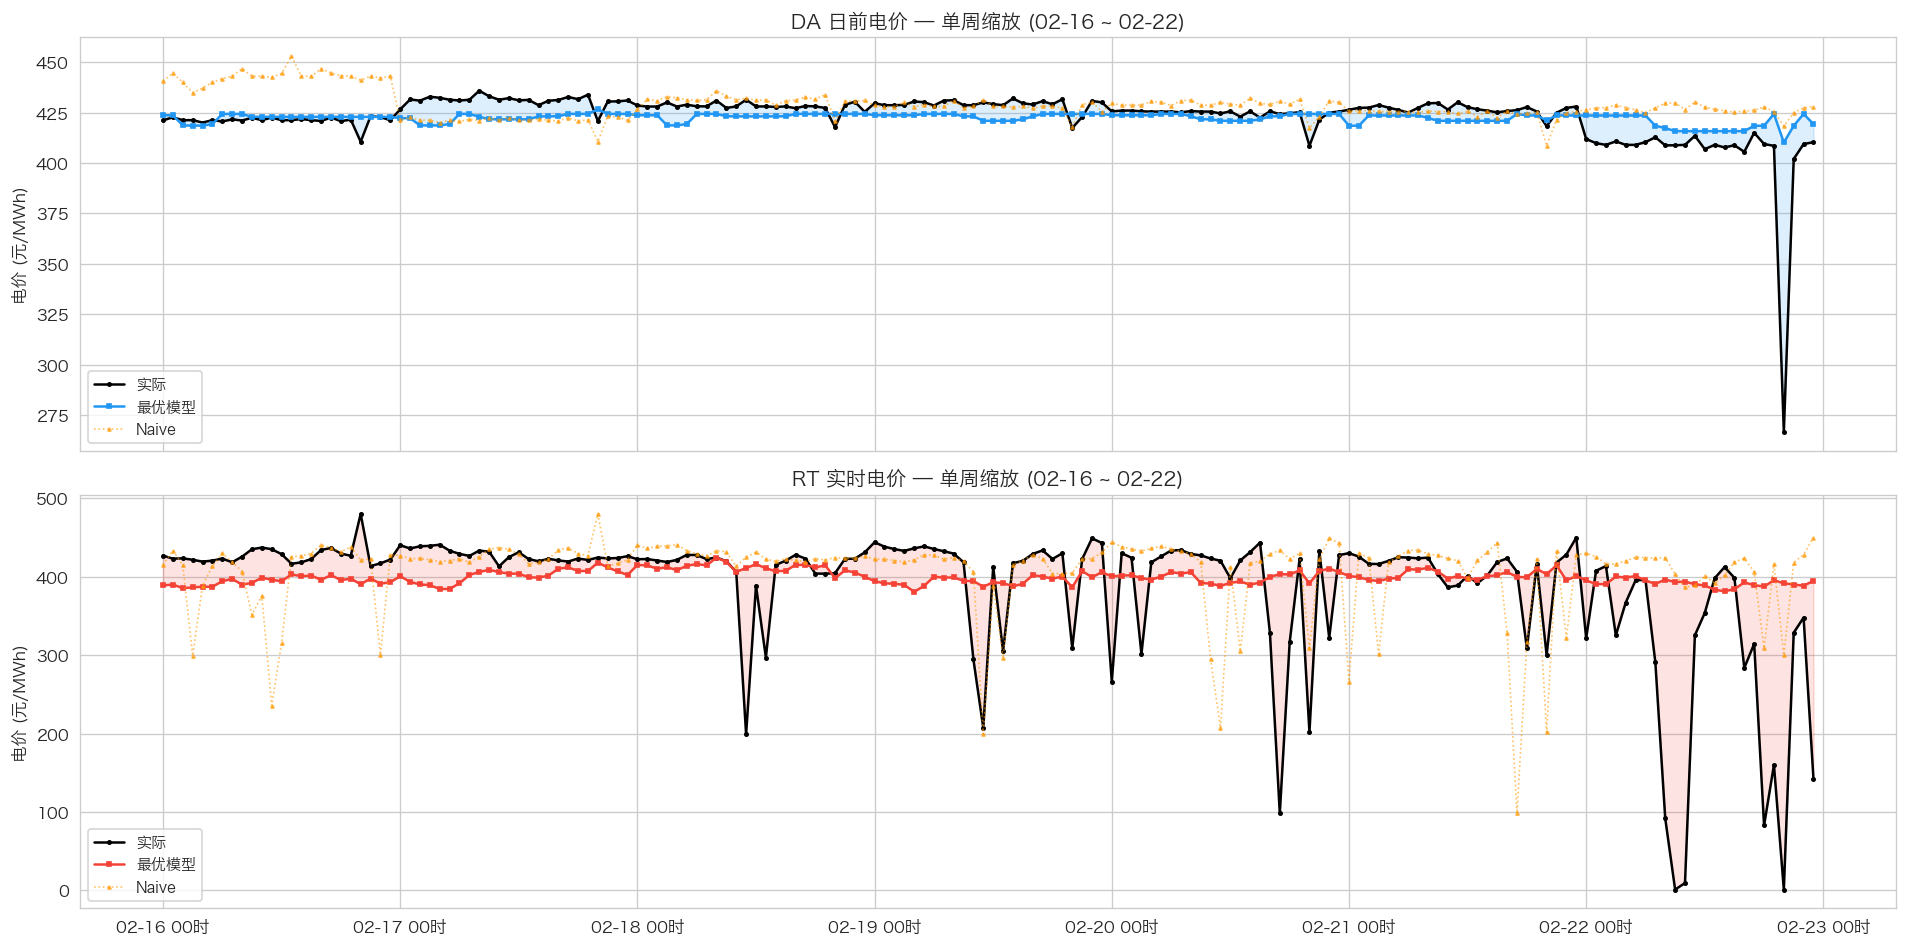

In [4]:
week_start = pd.Timestamp("2026-02-16 00:00:00")
week_end = pd.Timestamp("2026-02-22 23:00:00")

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, df, name, color in [
    (axes[0], da, "DA 日前电价", "#2196F3"),
    (axes[1], rt, "RT 实时电价", "#F44336"),
]:
    w = df.loc[week_start:week_end]
    ax.plot(w.index, w["actual"], "o-", color="black", markersize=2, linewidth=1.5, label="实际")
    ax.plot(w.index, w["pred_best"], "s-", color=color, markersize=2, linewidth=1.5, label="最优模型")
    ax.plot(w.index, w["pred_naive"], "^:", color="#FF9800", markersize=2, linewidth=1, alpha=0.6, label="Naive")
    ax.fill_between(w.index, w["actual"], w["pred_best"], alpha=0.15, color=color)
    ax.set_ylabel("电价 (元/MWh)")
    ax.set_title(f"{name} — 单周缩放 (02-16 ~ 02-22)", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H时"))

plt.tight_layout()
plt.savefig(f"{OUT}/final_zoom_week.png", bbox_inches="tight")
plt.show()

## 4. 散点图 + 残差分布

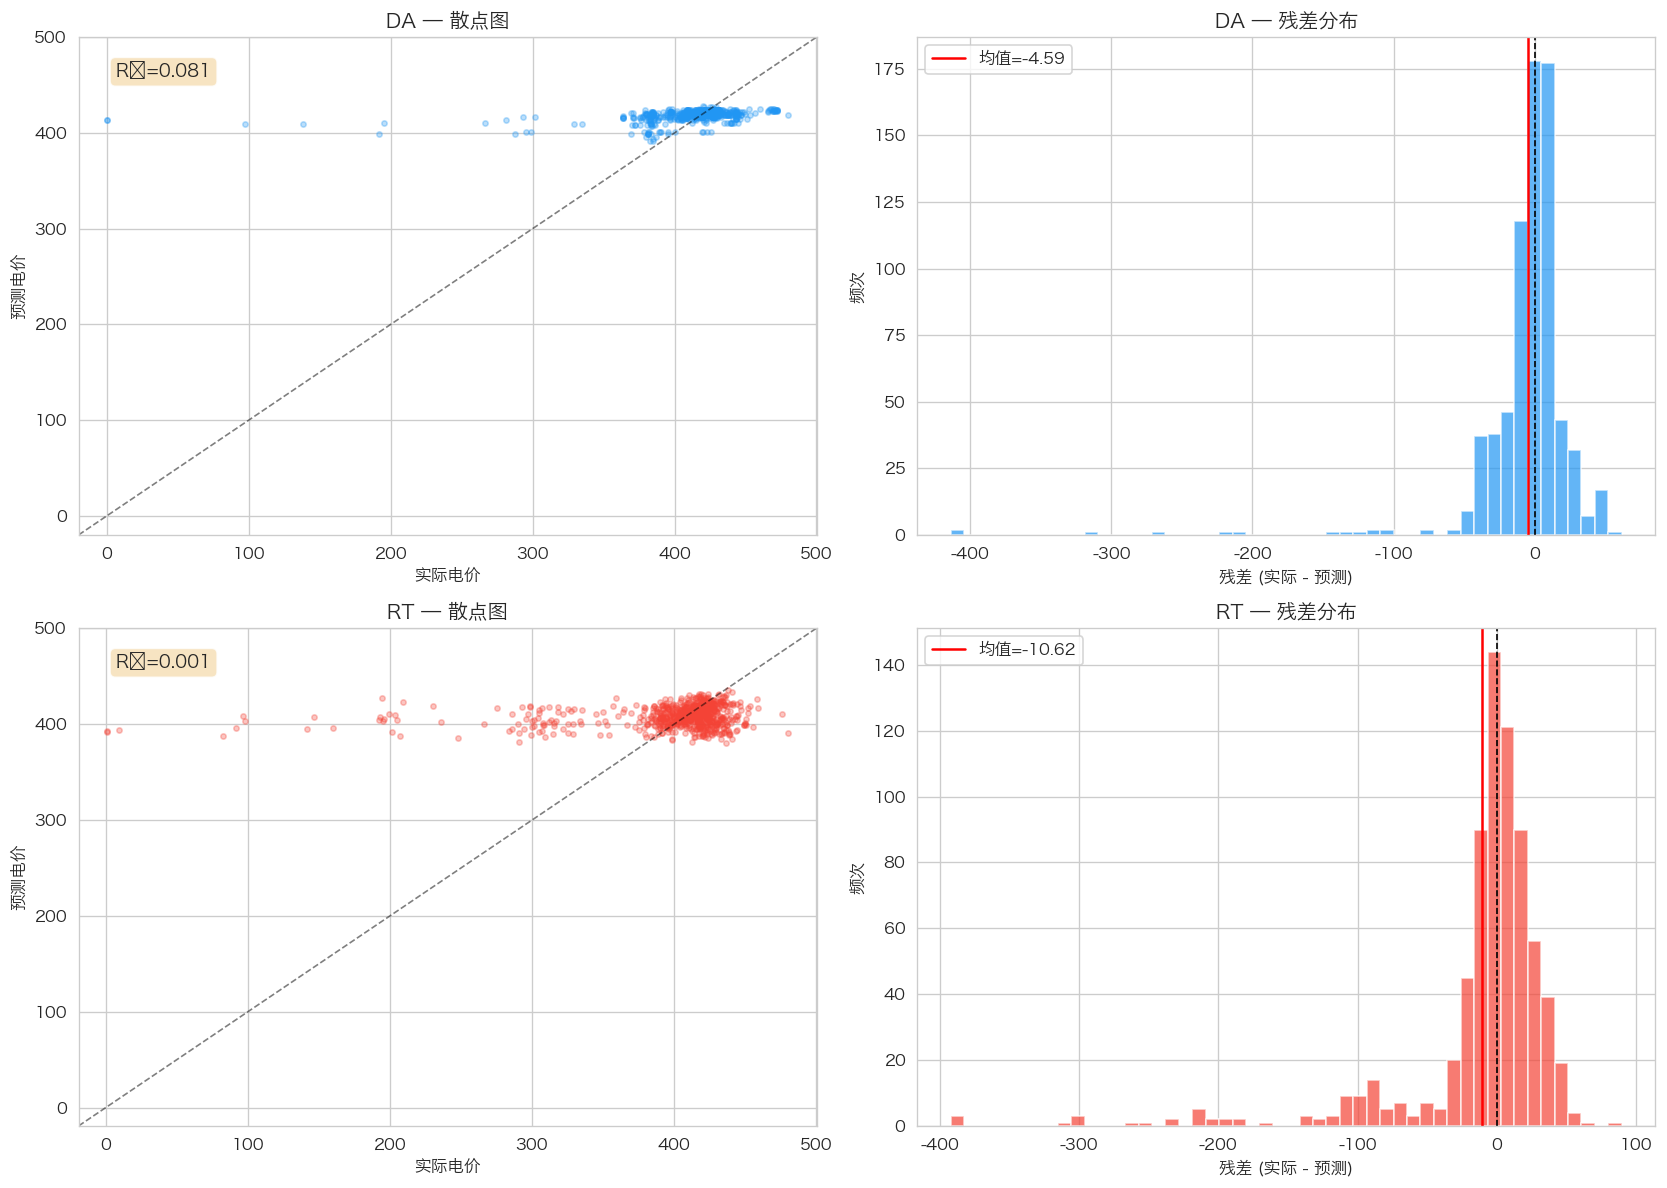

DA: 均值偏差=-4.59, std=36.08, P5=-38.6, P95=28.1
RT: 均值偏差=-10.62, std=55.92, P5=-109.1, P95=37.5


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, df, name, color in [
    (0, da, "DA", "#2196F3"),
    (1, rt, "RT", "#F44336"),
]:
    # Scatter
    ax = axes[row, 0]
    ax.scatter(df["actual"], df["pred_best"], alpha=0.3, s=10, color=color)
    lims = [min(df["actual"].min(), df["pred_best"].min()) - 20,
            max(df["actual"].max(), df["pred_best"].max()) + 20]
    ax.plot(lims, lims, "k--", linewidth=1, alpha=0.5)
    ax.set_xlabel("实际电价")
    ax.set_ylabel("预测电价")
    ax.set_title(f"{name} — 散点图", fontweight="bold")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    r2 = 1 - np.sum(df["residual"]**2) / np.sum((df["actual"] - df["actual"].mean())**2)
    ax.text(0.05, 0.92, f"R²={r2:.3f}", transform=ax.transAxes, fontsize=11,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

    # Residual histogram
    ax = axes[row, 1]
    ax.hist(df["residual"], bins=50, color=color, alpha=0.7, edgecolor="white")
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.axvline(df["residual"].mean(), color="red", linestyle="-", linewidth=1.5,
              label=f"均值={df['residual'].mean():.2f}")
    ax.set_xlabel("残差 (实际 - 预测)")
    ax.set_ylabel("频次")
    ax.set_title(f"{name} — 残差分布", fontweight="bold")
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f"{OUT}/final_scatter_residual.png", bbox_inches="tight")
plt.show()

for name, df in [("DA", da), ("RT", rt)]:
    r = df["residual"]
    print(f"{name}: 均值偏差={r.mean():.2f}, std={r.std():.2f}, "
          f"P5={r.quantile(0.05):.1f}, P95={r.quantile(0.95):.1f}")

## 5. 残差时序 + 自相关

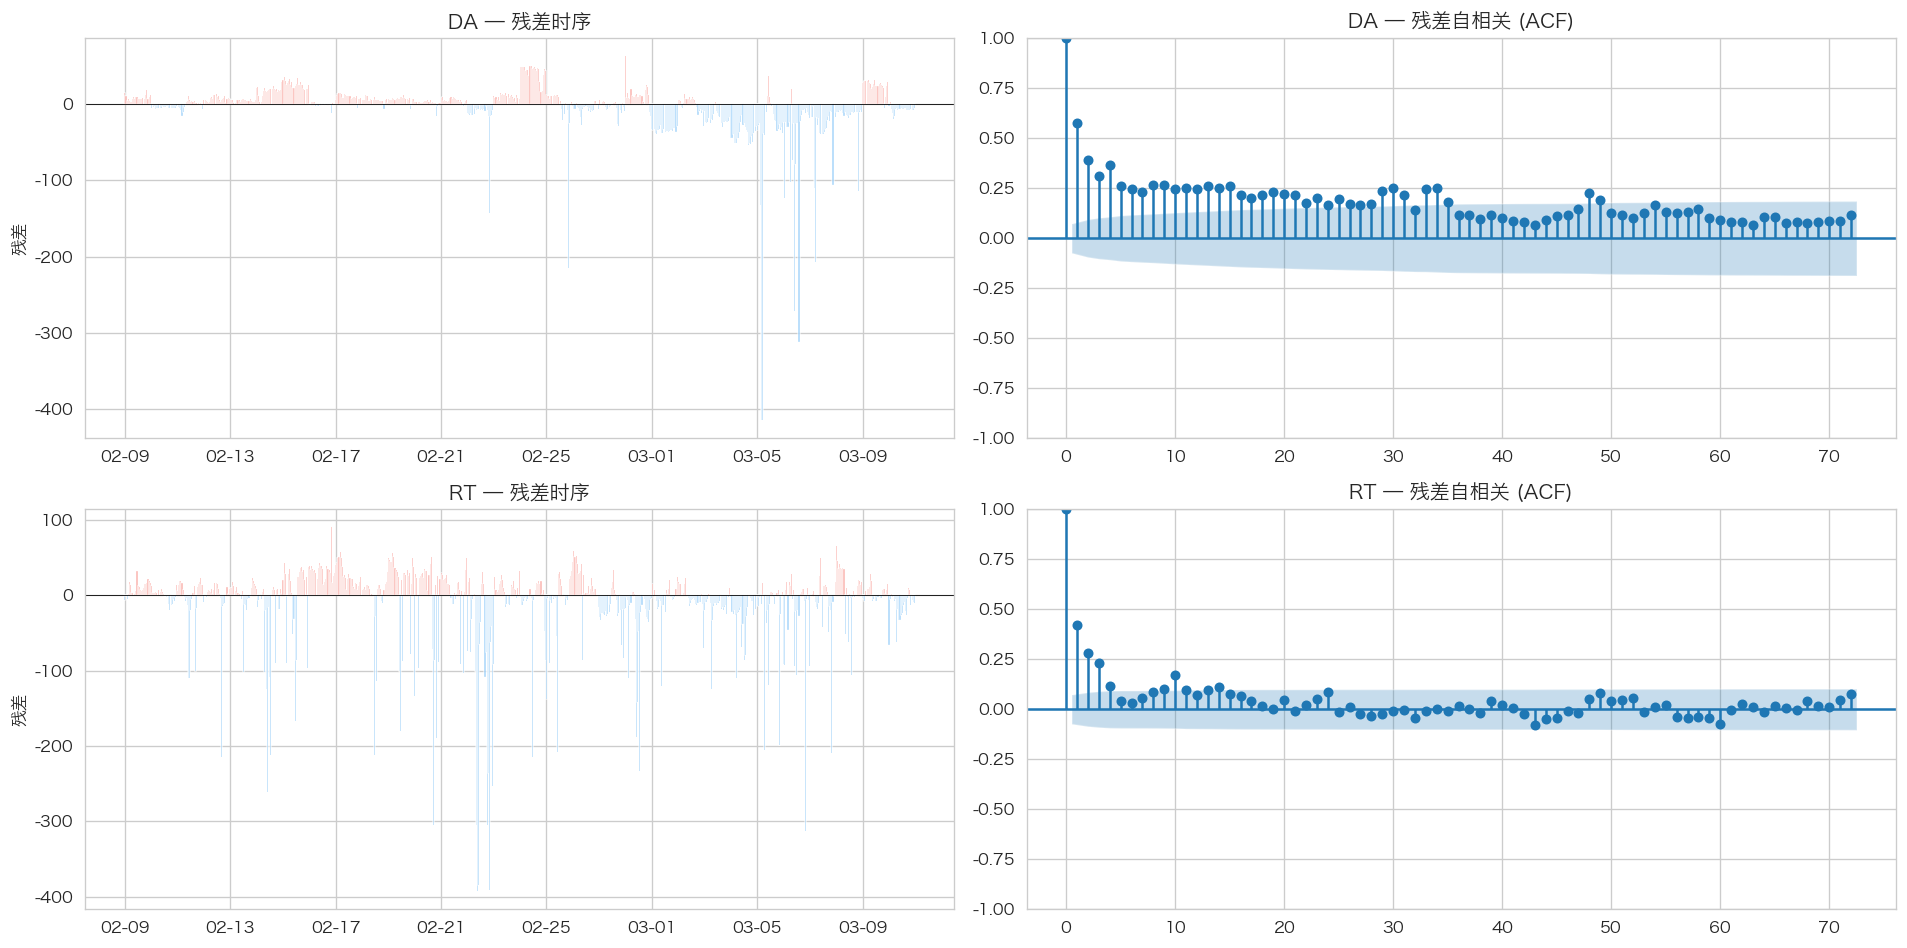

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for row, df, name, color in [(0, da, "DA", "#2196F3"), (1, rt, "RT", "#F44336")]:
    # Residual time series
    ax = axes[row, 0]
    ax.bar(df.index, df["residual"],
           color=np.where(df["residual"] > 0, "#F44336", "#2196F3"), alpha=0.6, width=0.04)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylabel("残差")
    ax.set_title(f"{name} — 残差时序", fontweight="bold")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

    # ACF
    ax = axes[row, 1]
    plot_acf(df["residual"].dropna(), lags=72, ax=ax, alpha=0.05,
             title=f"{name} — 残差自相关 (ACF)")

plt.tight_layout()
plt.savefig(f"{OUT}/final_residual_acf.png", bbox_inches="tight")
plt.show()

## 6. 按小时误差分布

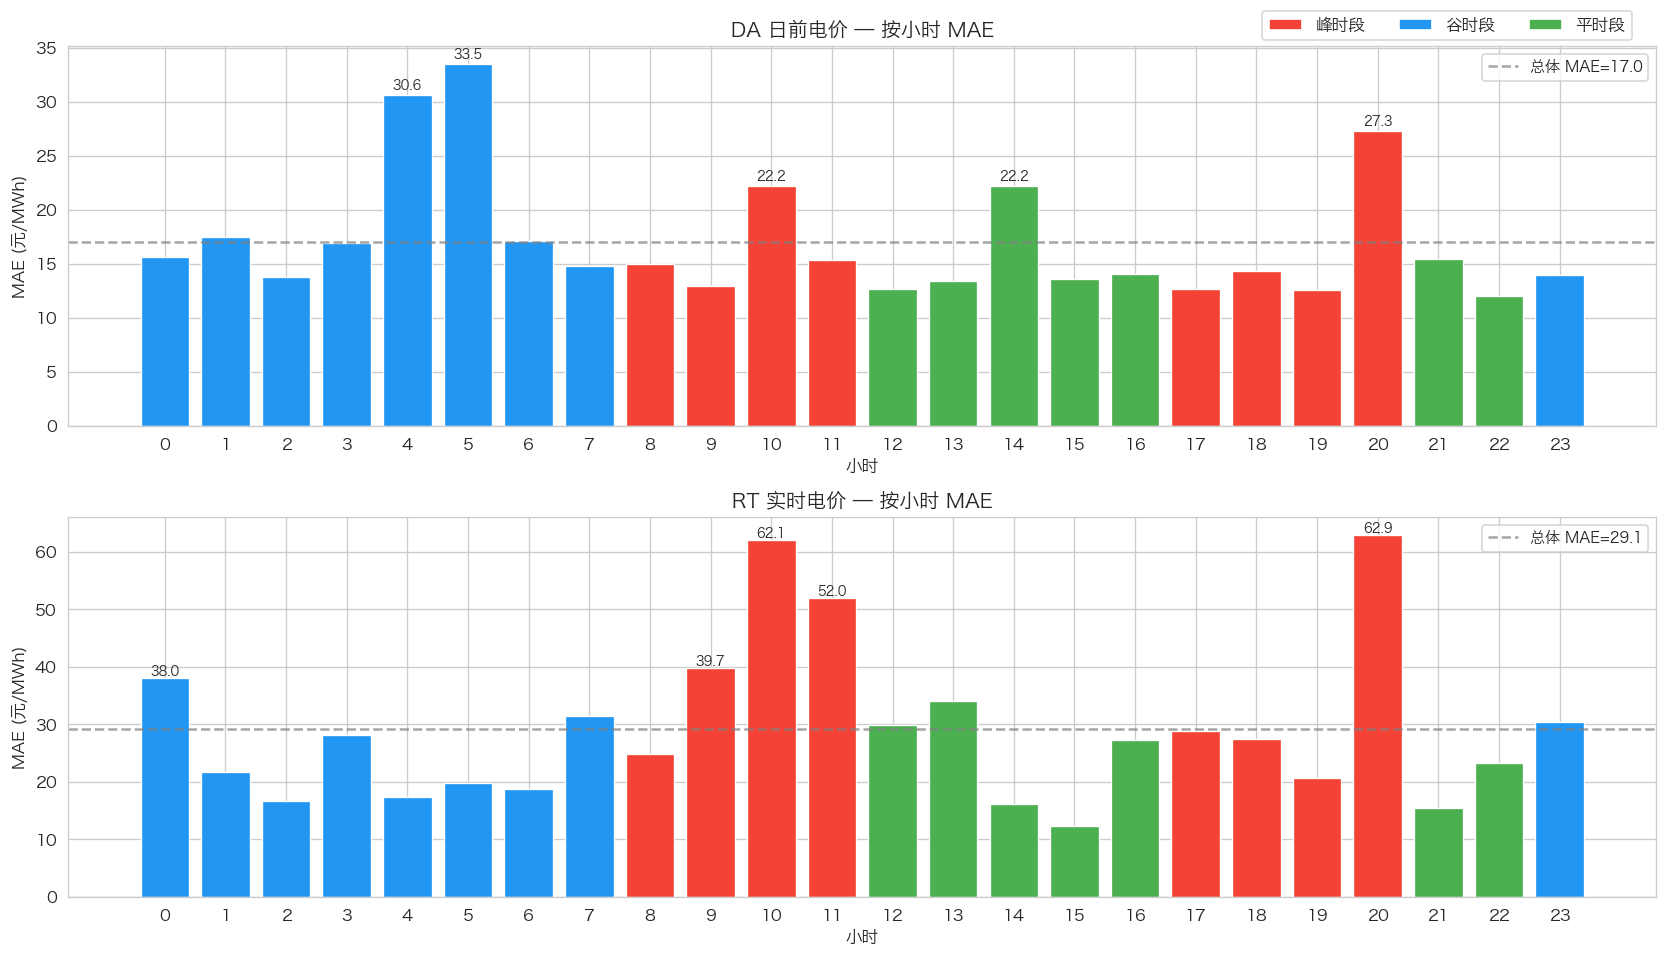

  DA 峰: MAE=16.53 (240样本)
  DA 谷: MAE=19.29 (270样本)
  DA 平: MAE=14.75 (210样本)
  RT 峰: MAE=39.80 (240样本)
  RT 谷: MAE=24.68 (270样本)
  RT 平: MAE=22.60 (210样本)


In [7]:
PEAK = set(range(8, 12)) | set(range(17, 21))
VALLEY = set(range(0, 8)) | {23}

def period_color(h):
    if h in PEAK: return "#F44336"
    if h in VALLEY: return "#2196F3"
    return "#4CAF50"

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, df, name in [(axes[0], da, "DA 日前电价"), (axes[1], rt, "RT 实时电价")]:
    hourly = df.groupby("hour")["residual"].apply(lambda x: np.mean(np.abs(x)))
    bar_colors = [period_color(h) for h in range(24)]
    bars = ax.bar(range(24), hourly.values, color=bar_colors, edgecolor="white", linewidth=0.8)
    ax.set_xlabel("小时")
    ax.set_ylabel("MAE (元/MWh)")
    ax.set_title(f"{name} — 按小时 MAE", fontsize=12, fontweight="bold")
    ax.set_xticks(range(24))
    overall_mae = np.mean(np.abs(df["residual"]))
    ax.axhline(overall_mae, color="gray", linestyle="--", alpha=0.7, label=f"总体 MAE={overall_mae:.1f}")
    ax.legend(fontsize=9)

    for i, v in enumerate(hourly.values):
        if v > overall_mae * 1.3:
            ax.text(i, v + 0.5, f"{v:.1f}", ha="center", fontsize=8, fontweight="bold")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#F44336", label="峰时段"),
    Patch(facecolor="#2196F3", label="谷时段"),
    Patch(facecolor="#4CAF50", label="平时段"),
]
fig.legend(handles=legend_elements, loc="upper right", fontsize=10, ncol=3,
           bbox_to_anchor=(0.98, 1.0))

plt.tight_layout()
plt.savefig(f"{OUT}/final_hourly_mae.png", bbox_inches="tight")
plt.show()

# Peak/Valley/Flat summary
for name, df in [("DA", da), ("RT", rt)]:
    for pname, hours in [("峰", PEAK), ("谷", VALLEY), ("平", set(range(24))-PEAK-VALLEY)]:
        sub = df[df["hour"].isin(hours)]
        mae = np.mean(np.abs(sub["residual"]))
        print(f"  {name} {pname}: MAE={mae:.2f} ({len(sub)}样本)")

## 7. 按日期误差 + 高误差日剖析

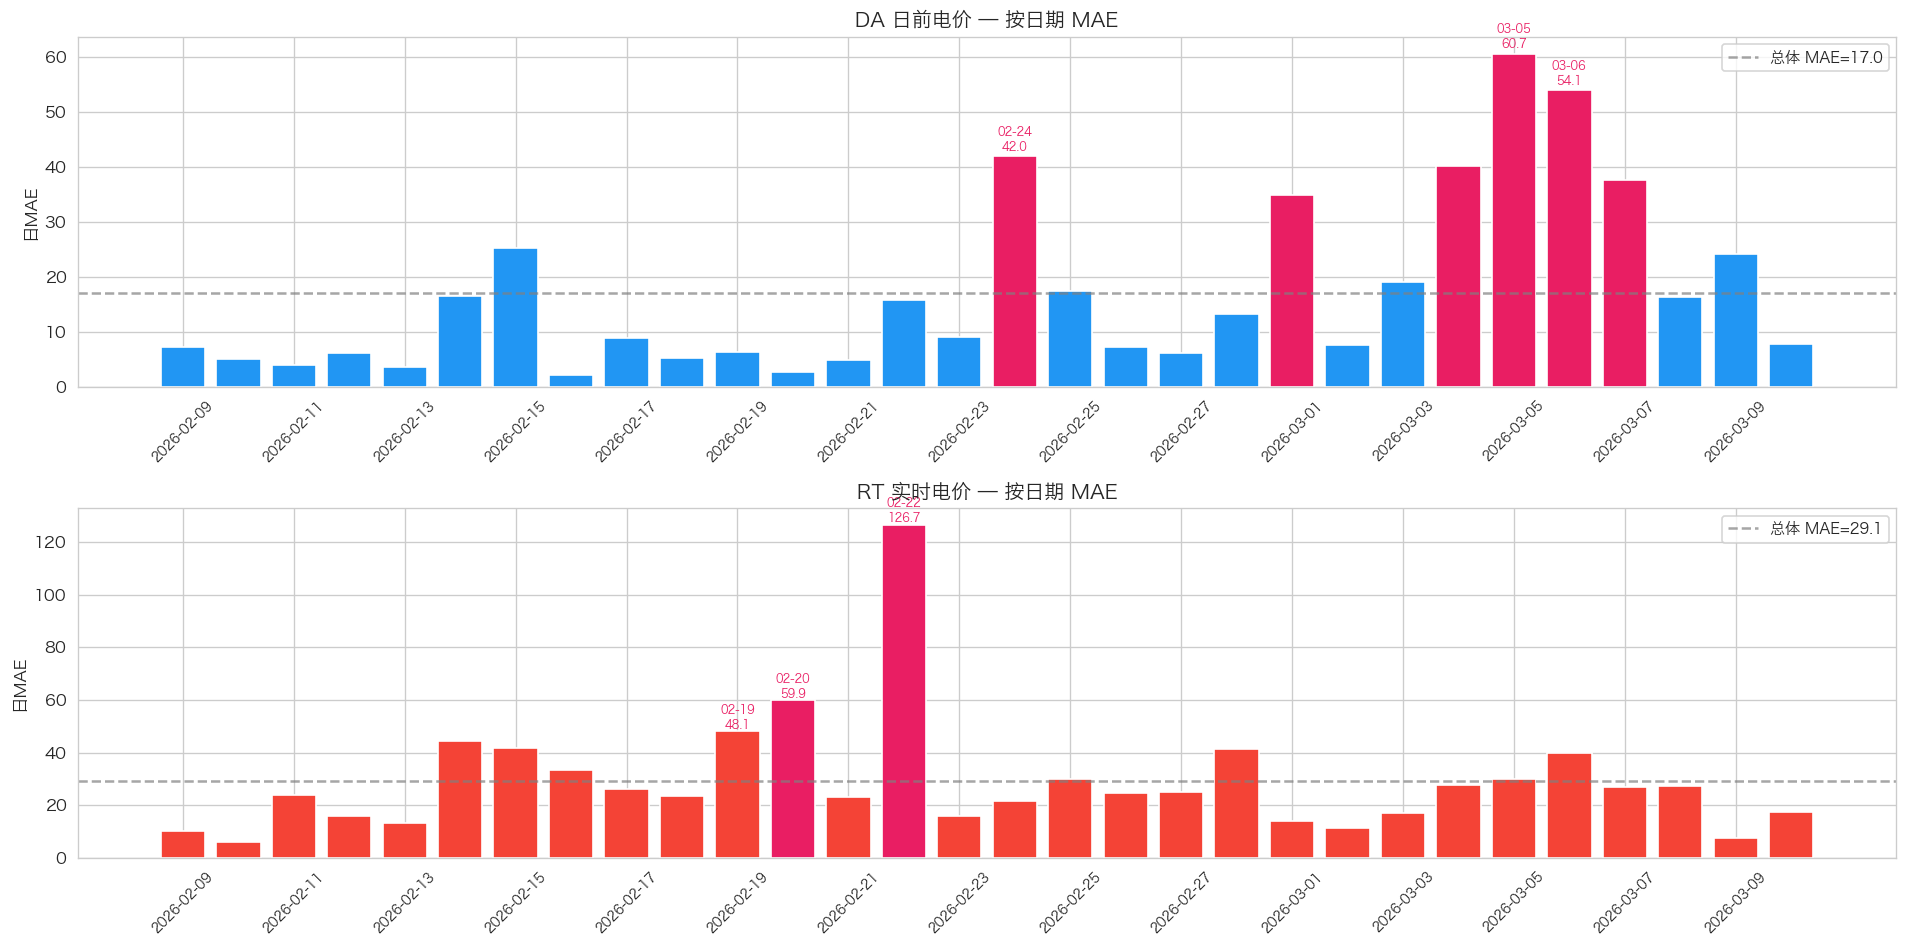

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

for ax, df, name, color in [
    (axes[0], da, "DA 日前电价", "#2196F3"),
    (axes[1], rt, "RT 实时电价", "#F44336"),
]:
    daily = df.groupby("date")["residual"].apply(lambda x: np.mean(np.abs(x))).reset_index()
    daily.columns = ["date", "mae"]
    overall_mae = np.mean(np.abs(df["residual"]))

    bar_colors = ["#E91E63" if m > overall_mae * 2 else color for m in daily["mae"]]
    ax.bar(range(len(daily)), daily["mae"], color=bar_colors, edgecolor="white")
    ax.axhline(overall_mae, color="gray", linestyle="--", alpha=0.7, label=f"总体 MAE={overall_mae:.1f}")
    ax.set_ylabel("日MAE")
    ax.set_title(f"{name} — 按日期 MAE", fontsize=12, fontweight="bold")

    step = max(1, len(daily) // 15)
    ax.set_xticks(range(0, len(daily), step))
    ax.set_xticklabels([str(d) for d in daily["date"].values[::step]], rotation=45, fontsize=8)
    ax.legend(fontsize=9)

    # Annotate worst days
    worst3 = daily.nlargest(3, "mae")
    for _, row in worst3.iterrows():
        idx = daily[daily["date"] == row["date"]].index[0]
        ax.text(idx, row["mae"] + 1, f"{str(row['date'])[5:]}\n{row['mae']:.1f}",
                ha="center", fontsize=7, fontweight="bold", color="#E91E63")

plt.tight_layout()
plt.savefig(f"{OUT}/final_daily_mae.png", bbox_inches="tight")
plt.show()

## 8. 高误差日 — 日内曲线剖析

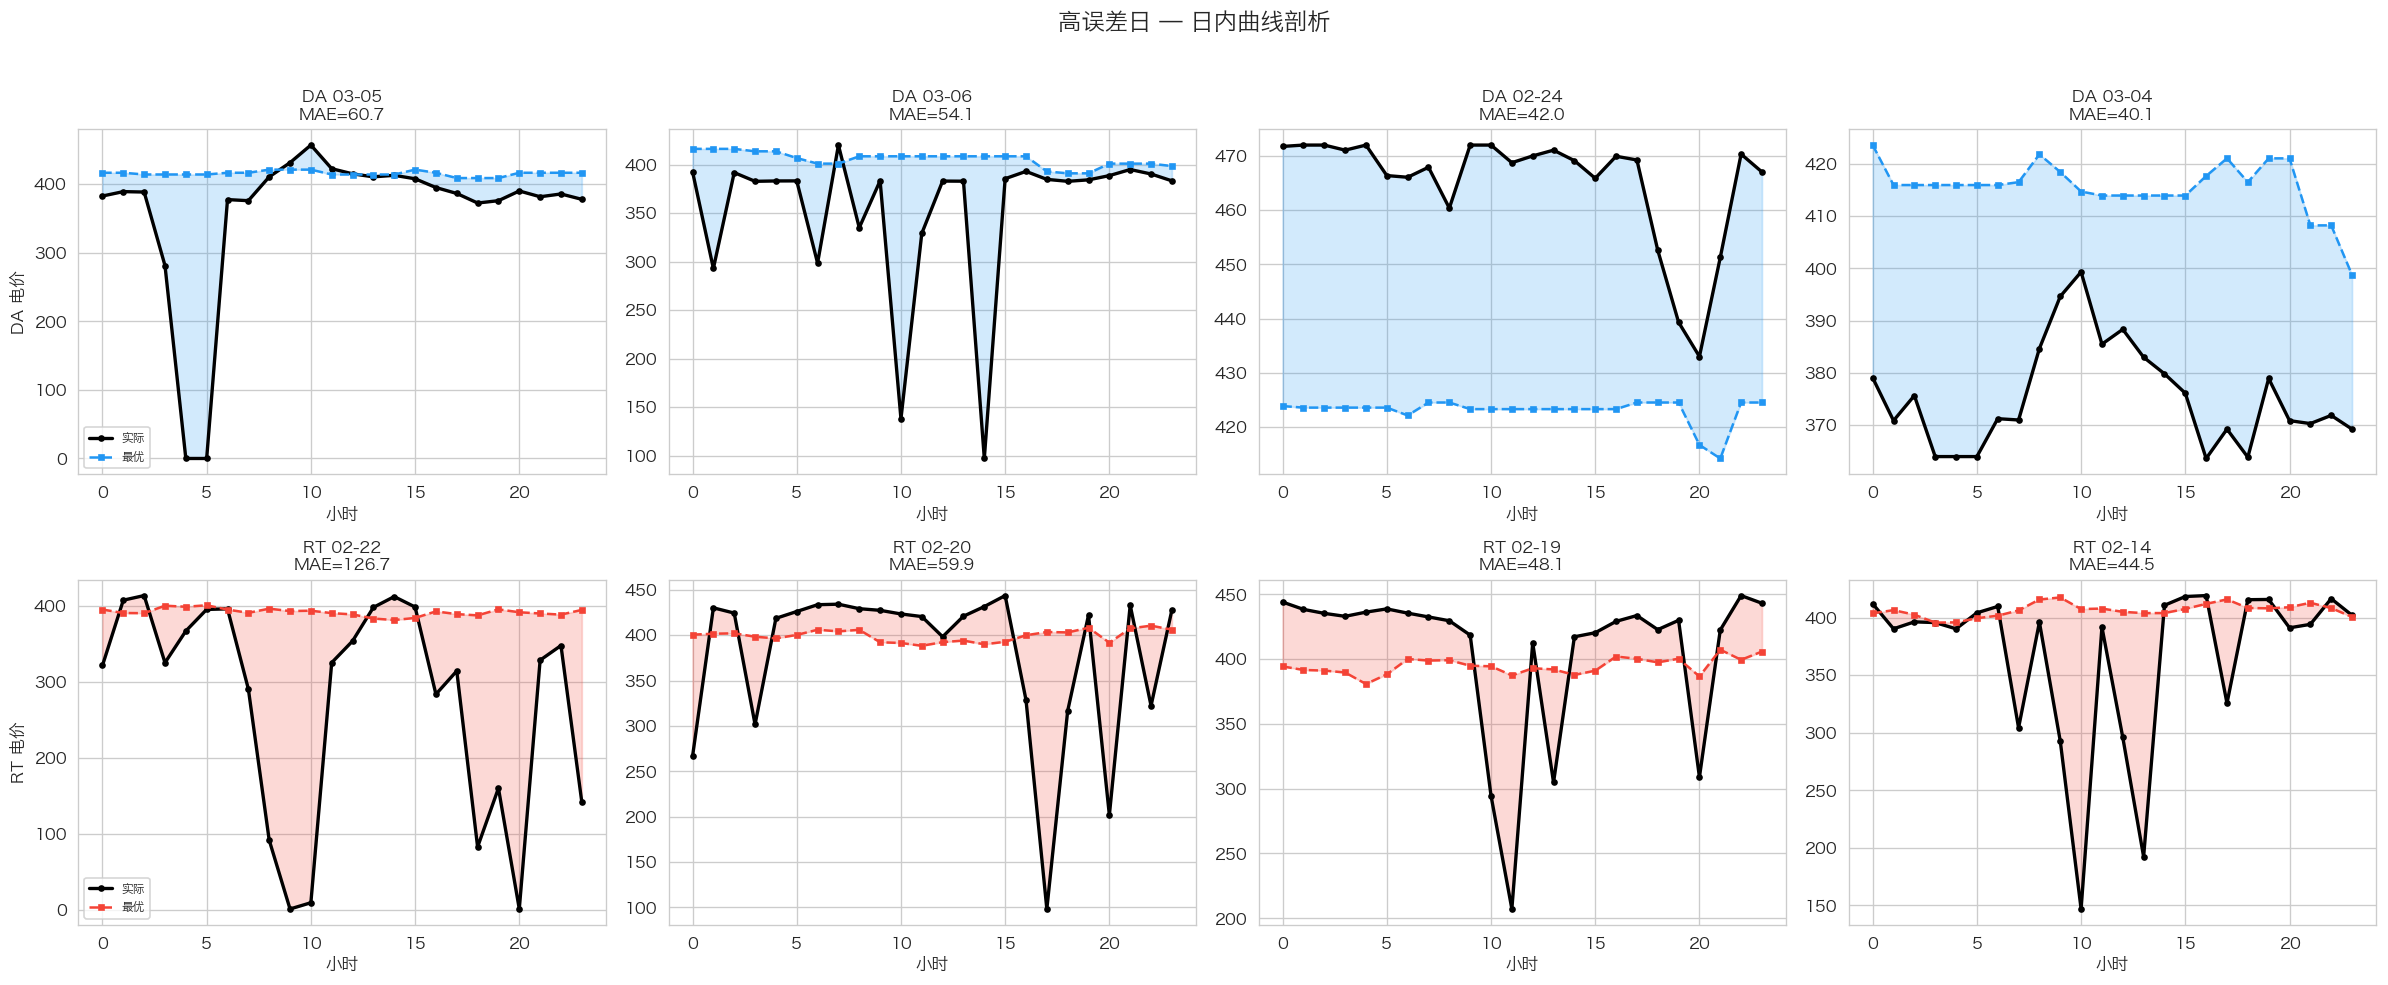

In [9]:
# Find worst 4 days for each model
da_daily = da.groupby("date")["residual"].apply(lambda x: np.mean(np.abs(x)))
rt_daily = rt.groupby("date")["residual"].apply(lambda x: np.mean(np.abs(x)))
da_worst4 = da_daily.nlargest(4).index.tolist()
rt_worst4 = rt_daily.nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for col, d in enumerate(da_worst4):
    ax = axes[0, col]
    day = da[da["date"] == d]
    ax.plot(day["hour"], day["actual"], "o-", color="black", linewidth=2, markersize=3, label="实际")
    ax.plot(day["hour"], day["pred_best"], "s--", color="#2196F3", linewidth=1.5, markersize=3, label="最优")
    ax.fill_between(day["hour"], day["actual"], day["pred_best"], alpha=0.2, color="#2196F3")
    mae = np.mean(np.abs(day["residual"]))
    ax.set_title(f"DA {str(d)[5:]}\nMAE={mae:.1f}", fontsize=10, fontweight="bold")
    if col == 0:
        ax.set_ylabel("DA 电价")
        ax.legend(fontsize=7)
    ax.set_xlabel("小时")

for col, d in enumerate(rt_worst4):
    ax = axes[1, col]
    day = rt[rt["date"] == d]
    ax.plot(day["hour"], day["actual"], "o-", color="black", linewidth=2, markersize=3, label="实际")
    ax.plot(day["hour"], day["pred_best"], "s--", color="#F44336", linewidth=1.5, markersize=3, label="最优")
    ax.fill_between(day["hour"], day["actual"], day["pred_best"], alpha=0.2, color="#F44336")
    mae = np.mean(np.abs(day["residual"]))
    ax.set_title(f"RT {str(d)[5:]}\nMAE={mae:.1f}", fontsize=10, fontweight="bold")
    if col == 0:
        ax.set_ylabel("RT 电价")
        ax.legend(fontsize=7)
    ax.set_xlabel("小时")

plt.suptitle("高误差日 — 日内曲线剖析", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT}/final_worst_days.png", bbox_inches="tight")
plt.show()

## 9. 各方法横向对比

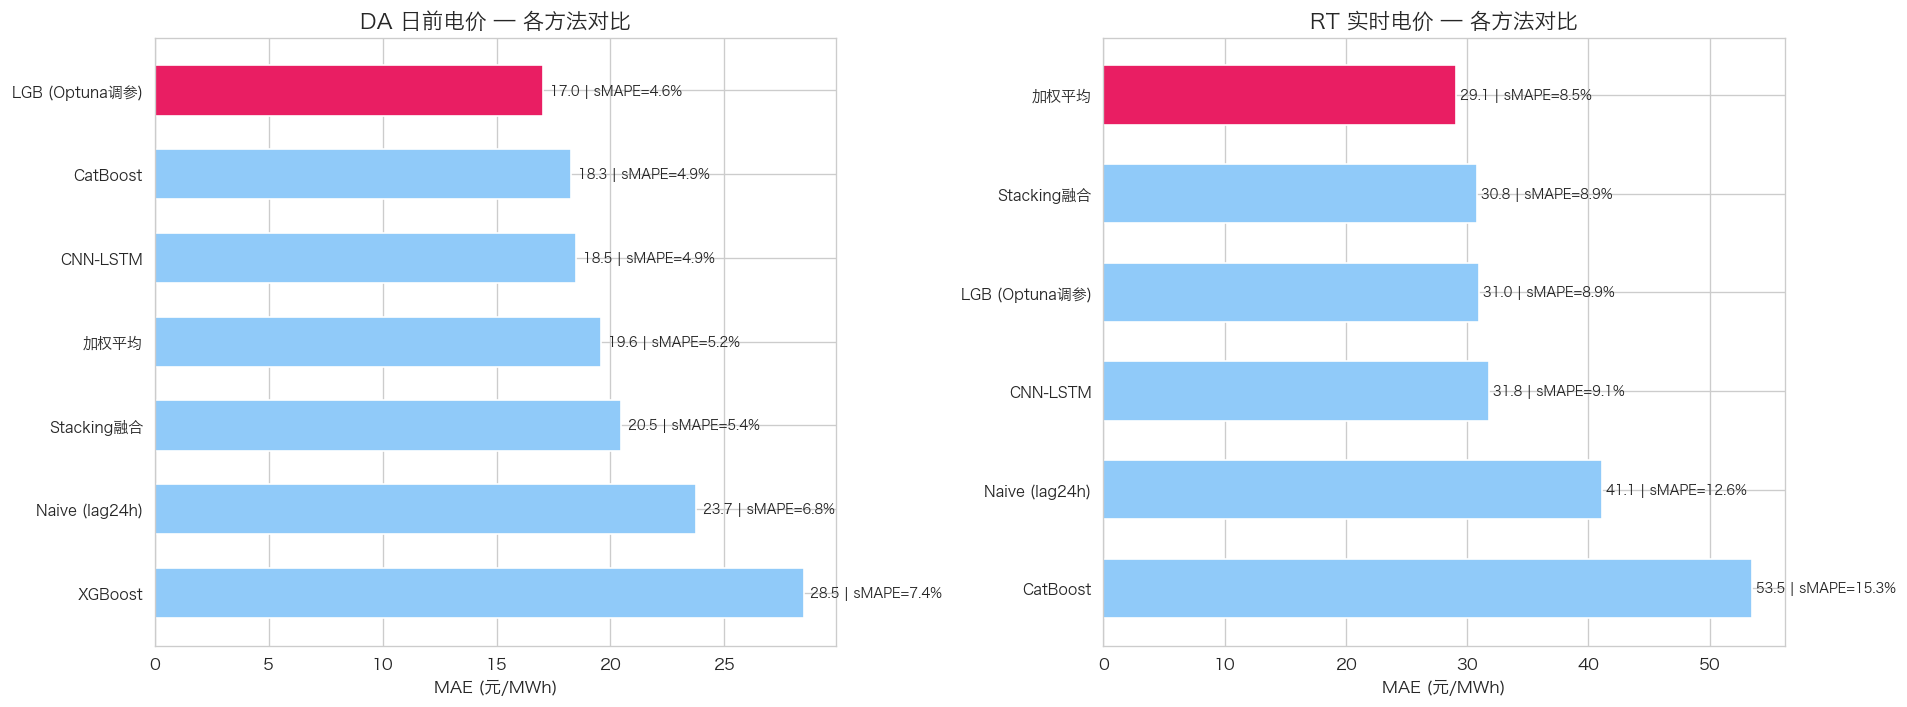

In [10]:
def calc_mae(actual, pred):
    mask = np.isfinite(actual) & np.isfinite(pred)
    return np.mean(np.abs(actual[mask] - pred[mask]))

def calc_smape(actual, pred):
    mask = np.isfinite(actual) & np.isfinite(pred)
    a, p = actual[mask], pred[mask]
    denom = (np.abs(a) + np.abs(p)) / 2
    valid = denom > 1e-6
    return np.mean(np.abs(a[valid] - p[valid]) / denom[valid]) * 100

# DA methods
da_methods = {
    "Naive (lag24h)": da["pred_naive"].values,
    "LGB (Optuna调参)": da["pred_best"].values,
    "XGBoost": ens_da["pred_xgb"].values,
    "CatBoost": ens_da["pred_cb"].values,
    "Stacking融合": ens_da["pred_stacking"].values,
    "加权平均": ens_da["pred_wavg"].values,
    "CNN-LSTM": seq_da["pred_seq"].values,
}

rt_methods = {
    "Naive (lag24h)": rt["pred_naive"].values,
    "LGB (Optuna调参)": ens_rt["pred_lgb"].values,
    "XGBoost": ens_rt["pred_xgb"].values,
    "CatBoost": ens_rt["pred_cb"].values,
    "Stacking融合": ens_rt["pred_stacking"].values,
    "加权平均": rt["pred_best"].values,
    "CNN-LSTM": seq_rt["pred_seq"].values,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, methods, actual_vals, title in [
    (axes[0], da_methods, da["actual"].values, "DA 日前电价"),
    (axes[1], rt_methods, rt["actual"].values, "RT 实时电价"),
]:
    names = list(methods.keys())
    maes = [calc_mae(actual_vals, v) for v in methods.values()]
    smapes = [calc_smape(actual_vals, v) for v in methods.values()]

    # Filter out XGB for RT (it failed)
    valid = [(n, m, s) for n, m, s in zip(names, maes, smapes) if m < 500]
    vn, vm, vs = zip(*valid)

    sorted_idx = np.argsort(vm)
    vn = [vn[i] for i in sorted_idx]
    vm = [vm[i] for i in sorted_idx]
    vs = [vs[i] for i in sorted_idx]

    colors_bar = ["#E91E63" if i == 0 else "#90CAF9" for i in range(len(vn))]
    colors_bar[0] = "#E91E63"

    y_pos = range(len(vn))
    bars = ax.barh(y_pos, vm, color=colors_bar, edgecolor="white", height=0.6)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(vn, fontsize=9)
    ax.set_xlabel("MAE (元/MWh)")
    ax.set_title(f"{title} — 各方法对比", fontsize=13, fontweight="bold")
    ax.invert_yaxis()

    for i, (mae_v, smape_v) in enumerate(zip(vm, vs)):
        ax.text(mae_v + 0.3, i, f"{mae_v:.1f} | sMAPE={smape_v:.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUT}/final_method_comparison.png", bbox_inches="tight")
plt.show()

## 10. 峰谷时段 — 最优模型表现对比

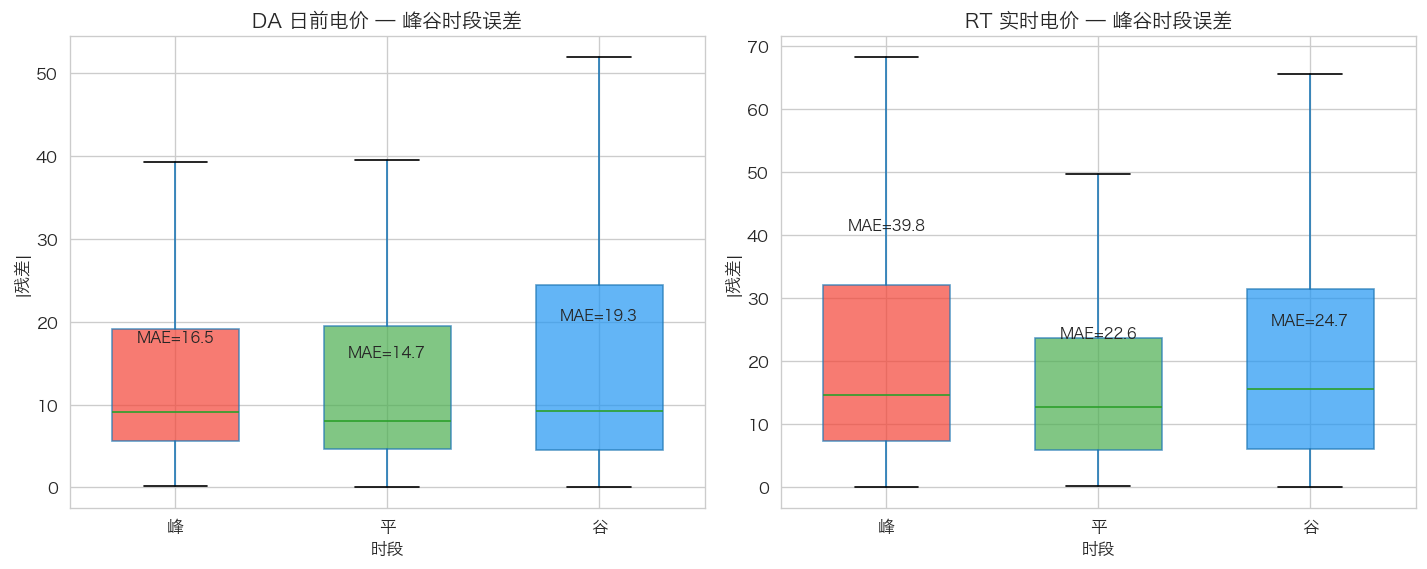

In [11]:
def period_label(h):
    if h in PEAK: return "峰"
    if h in VALLEY: return "谷"
    return "平"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, name, pal in [
    (axes[0], da, "DA 日前电价", ["#F44336", "#4CAF50", "#2196F3"]),
    (axes[1], rt, "RT 实时电价", ["#F44336", "#4CAF50", "#2196F3"]),
]:
    df["period"] = df["hour"].apply(period_label)
    df["abs_residual"] = df["residual"].abs()

    order = ["峰", "平", "谷"]
    bp = df.boxplot(column="abs_residual", by="period", ax=ax, positions=[0,1,2],
                    widths=0.6, patch_artist=True, showfliers=False,
                    return_type="dict")
    for patch, color in zip(bp["abs_residual"]["boxes"], pal):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    stats = df.groupby("period")["abs_residual"].agg(["mean", "median"])
    for i, p in enumerate(order):
        if p in stats.index:
            ax.text(i, stats.loc[p, "mean"] + 1, f"MAE={stats.loc[p, 'mean']:.1f}",
                    ha="center", fontsize=9, fontweight="bold")

    ax.set_title(f"{name} — 峰谷时段误差", fontsize=12, fontweight="bold")
    ax.set_xlabel("时段")
    ax.set_ylabel("|残差|")
    ax.set_xticklabels(order)
    fig.suptitle("")

plt.tight_layout()
plt.savefig(f"{OUT}/final_period_comparison.png", bbox_inches="tight")
plt.show()

## 11. 综合评估总结

In [12]:
print("=" * 70)
print("最优模型综合评估")
print("=" * 70)

for name, df, model_desc in [
    ("DA", da, "LGB Optuna调参"),
    ("RT", rt, "LGB+CatBoost 加权平均"),
]:
    r = df["residual"]
    mae = np.mean(np.abs(r))
    rmse = np.sqrt(np.mean(r**2))
    denom = (np.abs(df["actual"]) + np.abs(df["pred_best"])) / 2
    valid = denom > 1e-6
    smape = np.mean(np.abs(r[valid]) / denom[valid]) * 100
    wmape = np.sum(np.abs(r)) / np.sum(np.abs(df["actual"])) * 100

    naive_r = df["actual"] - df["pred_naive"]
    naive_mae = np.mean(np.abs(naive_r))
    improve = (1 - mae / naive_mae) * 100

    print(f"\n【{name} — {model_desc}】")
    print(f"  MAE  = {mae:.2f} 元/MWh")
    print(f"  RMSE = {rmse:.2f} 元/MWh")
    print(f"  sMAPE = {smape:.2f}%")
    print(f"  wMAPE = {wmape:.2f}%")
    print(f"  vs Naive: {naive_mae:.2f} → {mae:.2f}, 提升 {improve:.1f}%")
    print(f"  偏差: 均值={r.mean():.2f} ({'偏低估' if r.mean()>0 else '偏高估'})")
    print(f"  极端残差: [{r.min():.1f}, {r.max():.1f}]")

    # Period breakdown
    for pname, hours in [("峰", PEAK), ("谷", VALLEY), ("平", set(range(24))-PEAK-VALLEY)]:
        sub = df[df["hour"].isin(hours)]
        pmae = np.mean(np.abs(sub["residual"]))
        print(f"  {pname}时段 MAE = {pmae:.2f} ({len(sub)}h)")

    # Worst 5 days
    daily_mae = df.groupby("date")["residual"].apply(lambda x: np.mean(np.abs(x))).sort_values(ascending=False)
    print(f"  最差5天:")
    for d, m in daily_mae.head(5).items():
        print(f"    {d}: MAE={m:.1f}")

print("\n" + "=" * 70)
print("迭代效果汇总")
print("=" * 70)
print(summary.to_string(index=False))
print("\n各方案有效性:")
findings = [
    ("特征扩充(+20列)", "最有效", "同小时历史均价成为DA Top1特征"),
    ("Optuna超参搜索", "小幅有效", "DA MAE 17.30→17.05"),
    ("多模型集成(LGB+CB)", "RT有效", "RT MAE 31.03→29.11"),
    ("分时段建模", "无效", "数据量不足导致退化"),
    ("残差AR修正", "无效", "滞后特征已覆盖时序结构"),
    ("CNN-LSTM", "无效", "数据量不足，不及树模型"),
]
for method, effect, note in findings:
    print(f"  {method}: [{effect}] {note}")

最优模型综合评估

【DA — LGB Optuna调参】
  MAE  = 17.05 元/MWh
  RMSE = 36.35 元/MWh
  sMAPE = 4.61%
  wMAPE = 4.11%
  vs Naive: 23.74 → 17.05, 提升 28.2%
  偏差: 均值=-4.59 (偏高估)
  极端残差: [-414.0, 61.8]
  峰时段 MAE = 16.53 (240h)
  谷时段 MAE = 19.29 (270h)
  平时段 MAE = 14.75 (210h)
  最差5天:
    2026-03-05: MAE=60.7
    2026-03-06: MAE=54.1
    2026-02-24: MAE=42.0
    2026-03-04: MAE=40.1
    2026-03-07: MAE=37.7

【RT — LGB+CatBoost 加权平均】
  MAE  = 29.11 元/MWh
  RMSE = 56.88 元/MWh
  sMAPE = 8.50%
  wMAPE = 7.32%
  vs Naive: 41.14 → 29.11, 提升 29.2%
  偏差: 均值=-10.62 (偏高估)
  极端残差: [-392.3, 89.8]
  峰时段 MAE = 39.80 (240h)
  谷时段 MAE = 24.68 (270h)
  平时段 MAE = 22.60 (210h)
  最差5天:
    2026-02-22: MAE=126.7
    2026-02-20: MAE=59.9
    2026-02-19: MAE=48.1
    2026-02-14: MAE=44.5
    2026-02-15: MAE=41.6

迭代效果汇总
         stage  da_mae  da_smape  da_wmape  rt_mae  rt_smape  rt_wmape
   v1_baseline 17.5400       NaN       NaN 29.5000       NaN       NaN
   v2_baseline 17.2969      4.66      4.17 30.8288      8.83      7.